# Bank Marketing Prediction using Gradient Boosting

This notebook presents the implementation of a supervised machine learning model using the Bank Marketing dataset. The objective is to predict whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related features.

## Objective

The aim of this analysis is to build and evaluate a Gradient Boosting classification model for predicting the target variable `y`, which indicates whether a customer subscribed to a term deposit (`yes` or `no`).

Gradient Boosting was selected as the machine learning model for this part of the assignment because it is a powerful ensemble technique that improves prediction performance by combining multiple weak learners.

In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

## Dataset Size and Target Distribution

This step checks the total number of rows and columns in the dataset and examines the distribution of the target variable `y`.

The output shows that the dataset is imbalanced, with a much larger number of `no` responses than `yes` responses. This class imbalance may affect the model’s ability to predict the minority class.

In [3]:
print(df.shape)
print(df["y"].value_counts())

(45211, 17)
y
no     39922
yes     5289
Name: count, dtype: int64


## Feature and Target Separation

The dataset is divided into:

- `X`: input features used for prediction
- `y`: target variable to be predicted

The target values are converted from categorical labels (`yes`, `no`) into numeric form (`1`, `0`) so they can be used by the machine learning model.

In [4]:
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

## Train-Test Split

The dataset is split into training and testing sets using an 80:20 ratio.

- The training set is used to train the model
- The testing set is used to evaluate model performance on unseen data

Stratified sampling is applied to preserve the class distribution in both sets.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Identify Categorical and Numerical Features

The features are separated into categorical and numerical columns.

This is necessary because categorical features must be encoded into a numerical format before they can be used by the Gradient Boosting model.

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## Data Preprocessing and Model Pipeline

A preprocessing pipeline is created using:

- **OneHotEncoder** for categorical variables
- **Passthrough** for numerical variables

The preprocessing step is combined with the **Gradient Boosting Classifier** in a single pipeline. This ensures that data transformation and model training are performed in an organized and reproducible way.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

## Model Training

The Gradient Boosting model is trained using the training dataset.

This step allows the model to learn patterns from the input features and their relationship with the target variable.

In [9]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

## Model Prediction

After training, the model is used to make predictions on the test dataset.

These predictions are then compared with the actual values to evaluate model performance.

In [10]:
y_pred = model.predict(X_test)

## Model Evaluation

The model is evaluated using the following metrics:

- **Accuracy**
- **Confusion Matrix**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**

These metrics provide a more complete understanding of classification performance, especially because the dataset is imbalanced.

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9054517306203693
Confusion Matrix:
 [[7754  231]
 [ 624  434]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



## Results Interpretation

The Gradient Boosting model achieved the following performance:

- **Accuracy:** 90.55%
- **ROC-AUC:** 0.924
- **Precision (Yes):** 0.65
- **Recall (Yes):** 0.41
- **F1-score (Yes):** 0.50

The results show that the model performed well overall and had a strong ability to distinguish between the two classes. However, recall for the positive class (`yes`) was lower, meaning that the model failed to identify some actual subscribers. This is likely due to the imbalance in the dataset.

## ROC-AUC Evaluation

The ROC-AUC score is calculated to measure the model’s ability to distinguish between the two classes across different classification thresholds. This metric is especially useful for imbalanced datasets because it provides a broader view of model performance beyond accuracy alone.

In [20]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9240308210219303


## Hyperparameter Tuning / Improved Model

To improve model performance, a second Gradient Boosting model was created with adjusted hyperparameters. In this version, the number of estimators was increased, the learning rate was reduced, and tree depth was controlled to improve learning and reduce overfitting. The tuned model was then evaluated on the same test set and compared with the initial model.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

model2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_prob2 = model2.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob2))

Accuracy: 0.9062258100187991
Confusion Matrix:
 [[7756  229]
 [ 619  439]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.41      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

ROC-AUC: 0.9246389437662536


## Visualizations

Several visualizations are included to better understand the dataset and model performance:

1. **Target Class Distribution** – shows the imbalance in the dataset  
2. **Confusion Matrix** – shows correct and incorrect predictions  
3. **ROC Curve** – shows the model’s classification ability  
4. **Actual vs Predicted Counts** – compares real and predicted class counts  
5. **Feature Importance** – identifies the most influential variables

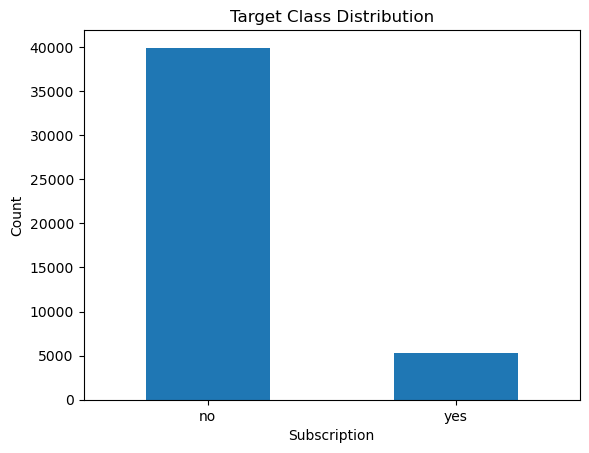

In [15]:
import matplotlib.pyplot as plt

df["y"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

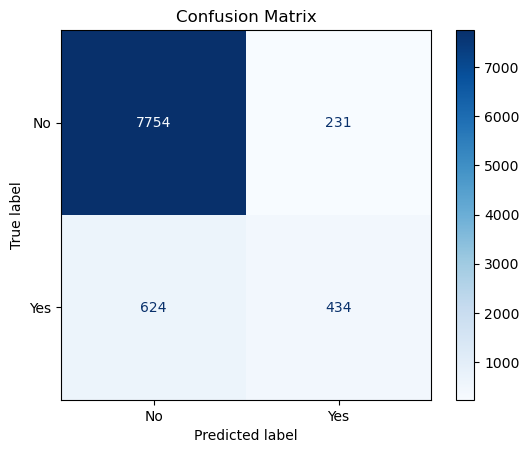

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

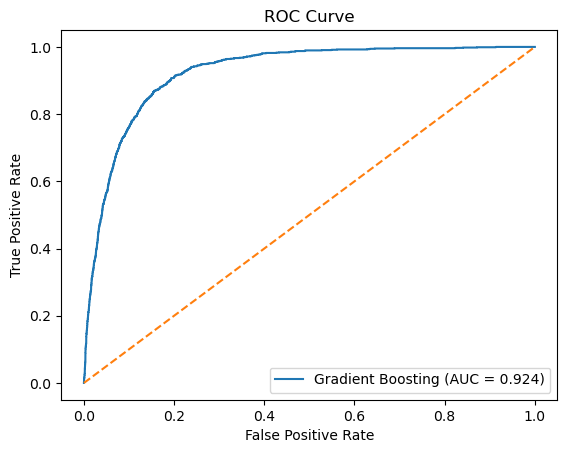

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

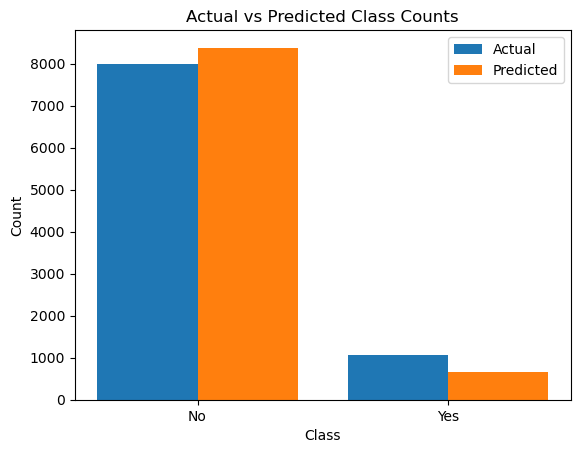

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

labels = ["No", "Yes"]
x = range(len(labels))

plt.bar(x, actual_counts, width=0.4, label="Actual", align="center")
plt.bar([i + 0.4 for i in x], pred_counts, width=0.4, label="Predicted", align="center")

plt.xticks([i + 0.2 for i in x], labels)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted Class Counts")
plt.legend()
plt.show()

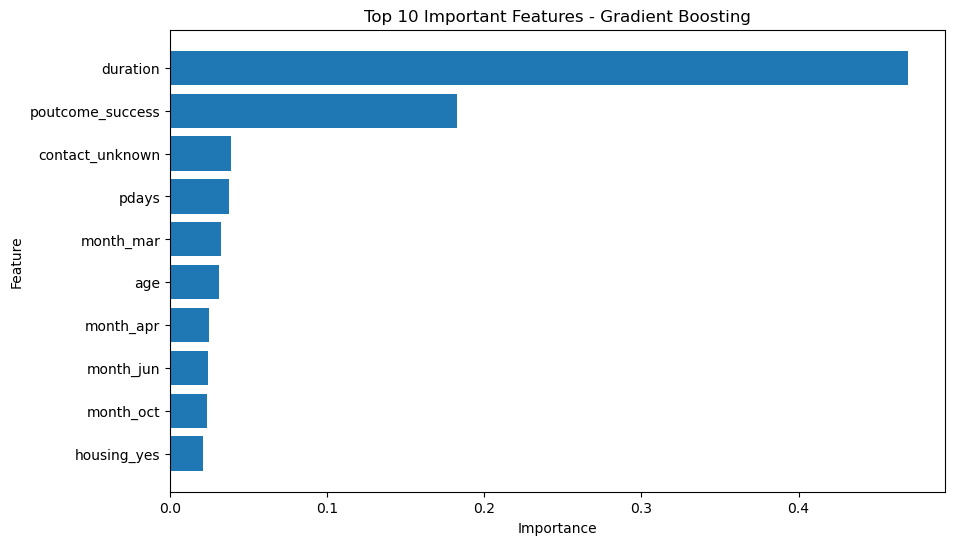

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = list(cat_features) + list(numerical_cols)

# Get feature importances
importances = model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10 features
top10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Interpretation of Visualizations

The target distribution chart confirms that the dataset is imbalanced, with significantly more `no` cases than `yes` cases.

The confusion matrix shows that the model correctly classified most negative cases, but missed a number of positive cases.

The ROC curve demonstrates strong model performance, with an AUC score of 0.924, indicating a high ability to distinguish between subscribers and non-subscribers.

The actual versus predicted class counts show that the model predicted more `no` cases and fewer `yes` cases, which is consistent with the class imbalance.

The feature importance chart indicates that `duration` was the most influential feature, followed by variables such as `poutcome_success`, `contact_unknown`, and `pdays`.

## Important Observation

The feature importance analysis shows that `duration` is the most significant predictor in the model. While this improves predictive performance, it may reduce real-world practicality because call duration is only known after the marketing call has taken place.

## Conclusion

In this notebook, a Gradient Boosting classifier was applied to the Bank Marketing dataset to predict whether a customer would subscribe to a term deposit.

The model achieved strong overall performance, with an accuracy of 90.55% and an ROC-AUC score of 0.924. Although the model performed very well on the majority class, recall for the minority class was lower, showing that some actual subscribers were not identified.

Overall, Gradient Boosting proved to be an effective supervised learning model for this classification problem.